<div style="padding: 20px; background-color: #f8f9fa; border-left: 10px solid #007bff; border-radius: 5px;">
    <h1 style="color: #007bff;">🏠 Post-Pandemic Housing Market Analysis</h1>
    <h3>Preprocessing & Feature Engineering Pipeline</h3>
    <p><b>Group 4 | 3CSE Machine Learning</b></p>
    <hr>
    <p><b>Objective:</b> This notebook processes Zillow Real Estate data to investigate non-linear determinants of housing prices during the WFH (Work From Home) era. We aim to bridge hyper-local price data with structural economic indicators to prepare a high-fidelity tensor for <b>Multiple Linear Regression</b> and <b>Decision Tree (CART)</b> modeling.</p>
</div>


## 🛠️ Environment Setup

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
import os

## 📂 Data Acquisition

In [ ]:
# 1. Mount Drive
drive.mount('/content/drive',force_remount=True)

# 2. Define your specific path
# Pro-tip: Use the full string exactly as it appears in Colab's file explorer
base_path = '/content/drive/MyDrive/3RD YEAR 2ND SEM/MACHINE LEARNING/3CSE Machine Learning Group 4/FINAL PROJECT/Dataset/'

# 3. List of your files (using the exact names you provided)
files = {
    'zhvi': 'metro_zhvi.csv',
    'rent': 'metro_zori.csv',
    'for_sale': 'metro_forsale.csv',
    'new_listings': 'metro_new_listings.csv',
    'days_pending': 'metro_med_days_to_pending.csv',
    'price_cuts': 'metro_shrlist_prcut.csv',
    'income_needed': 'metro_new_homeowner_income_needed.csv',
    'zhvi_1b': 'metro_zhvi_1_bdrm.csv',
    'zhvi_2b': 'metro_zhvi_2_bdrm.csv',
    'zhvi_3b': 'metro_zhvi_3_bdrm.csv',
    'zhvi_4b': 'metro_zhvi_4_bdrm.csv',
    'zhvi_5b': 'metro_zhvi_5plus_bdrm.csv',
    'market_heat_index': 'metro_market_heat_index.csv',
    'new_homeowner_affordability': 'metro_new_homeowner_affordability.csv'
}

Mounted at /content/drive


In [ ]:
# 4. Load dataframes into a dictionary
dfs = {}
print("--- Starting Data Load ---")
for key, filename in files.items():
    full_path = os.path.join(base_path, filename)
    if os.path.exists(full_path):
        dfs[key] = pd.read_csv(full_path)
        print(f"✅ Success: {key} loaded. Shape: {dfs[key].shape}")
    else:
        print(f"❌ Error: File not found at {full_path}")

--- Starting Data Load ---
✅ Success: zhvi loaded. Shape: (895, 320)
✅ Success: rent loaded. Shape: (719, 140)
✅ Success: for_sale loaded. Shape: (928, 102)
✅ Success: new_listings loaded. Shape: (927, 102)
✅ Success: days_pending loaded. Shape: (769, 102)
✅ Success: price_cuts loaded. Shape: (928, 102)
✅ Success: income_needed loaded. Shape: (390, 176)
✅ Success: zhvi_1b loaded. Shape: (671, 320)
✅ Success: zhvi_2b loaded. Shape: (851, 320)
✅ Success: zhvi_3b loaded. Shape: (884, 320)
✅ Success: zhvi_4b loaded. Shape: (855, 320)
✅ Success: zhvi_5b loaded. Shape: (758, 320)
✅ Success: market_heat_index loaded. Shape: (928, 104)
✅ Success: new_homeowner_affordability loaded. Shape: (390, 176)


## ⚙️ Data Reshaping & Structural Alignment

In [ ]:
def process_and_merge(dfs):
    # 1. THE MELT: Transforming horizontal date columns into vertical rows
    melted_dfs = {}
    id_vars = ['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName']

    print("--- Reshaping Data ---")
    for key, df in dfs.items():
        # Identify date columns (they start with '20' or '19')
        date_cols = [col for col in df.columns if col.startswith(('20', '19'))]

        # Melt the dataframe
        df_long = df.melt(id_vars=id_vars, value_vars=date_cols,
                          var_name='Date', value_name=key)

        # Convert Date string to datetime objects for accurate merging
        df_long['Date'] = pd.to_datetime(df_long['Date'])
        melted_dfs[key] = df_long
        print(f"Reshaped {key}...")

    # 2. THE MASTER MERGE: Stitching all 12 tables together
    # We start with 'zhvi' as our base anchor
    master_df = melted_dfs['zhvi']

    print("\n--- Merging Tables ---")
    # List of keys to merge (excluding the anchor 'zhvi')
    other_keys = [k for k in melted_dfs.keys() if k != 'zhvi']

    for key in other_keys:
        # We only need RegionID, Date, and the actual Data Value for the merge
        subset = melted_dfs[key][['RegionID', 'Date', key]]
        master_df = pd.merge(master_df, subset, on=['RegionID', 'Date'], how='left')
        print(f"Merged {key} into master...")

    # 3. FEATURE ENGINEERING: Creating non-linear proxies
    print("\n--- Engineering Features ---")

    # Space Premium: Ratio of 4-bedroom to 2-bedroom prices
    # Formula: $Space\_Premium = \frac{ZHVI_{4BR}}{ZHVI_{2BR}}$
    master_df['space_premium'] = master_df['zhvi_4b'] / master_df['zhvi_2b']

    # Era Toggle: Categorizing the market shift (Interest Rate Hike Era)
    # 0 = Pandemic/Low-Rate, 1 = Post-Pandemic/High-Rate
    master_df['is_post_pandemic'] = (master_df['Date'] >= '2022-04-01').astype(int)

    # 4. CLEANING: Handling missing values and sorting
    print("--- Cleaning & Filling Gaps ---")
    master_df = master_df.sort_values(['RegionID', 'Date'])

    # Forward-fill (carry last known value) then backward-fill within each Metro group
    master_df = master_df.groupby('RegionID').apply(lambda x: x.ffill().bfill()).reset_index(drop=True)

    # Drop rows that are still NaN (where no data exists for that Metro at all)
    master_df.dropna(inplace=True)

    return master_df

# Execute the pipeline
master_df = process_and_merge(dfs)
print(f"\nFinal Master Dataframe Shape: {master_df.shape}")

--- Reshaping Data ---
Reshaped zhvi...
Reshaped rent...
Reshaped for_sale...
Reshaped new_listings...
Reshaped days_pending...
Reshaped price_cuts...
Reshaped income_needed...
Reshaped zhvi_1b...
Reshaped zhvi_2b...
Reshaped zhvi_3b...
Reshaped zhvi_4b...
Reshaped zhvi_5b...
Reshaped market_heat_index...
Reshaped new_homeowner_affordability...

--- Merging Tables ---
Merged rent into master...
Merged for_sale into master...
Merged new_listings into master...
Merged days_pending into master...
Merged price_cuts into master...
Merged income_needed into master...
Merged zhvi_1b into master...
Merged zhvi_2b into master...
Merged zhvi_3b into master...
Merged zhvi_4b into master...
Merged zhvi_5b into master...
Merged market_heat_index into master...
Merged new_homeowner_affordability into master...

--- Engineering Features ---
--- Cleaning & Filling Gaps ---


/tmp/ipykernel_8099/576788114.py:50: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  master_df = master_df.groupby('RegionID').apply(lambda x: x.ffill().bfill()).reset_index(drop=True)



Final Master Dataframe Shape: (112455, 22)


/tmp/ipykernel_8099/576788114.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  master_df = master_df.groupby('RegionID').apply(lambda x: x.ffill().bfill()).reset_index(drop=True)


In [ ]:
master_df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,Date,zhvi,rent,for_sale,new_listings,...,income_needed,zhvi_1b,zhvi_2b,zhvi_3b,zhvi_4b,zhvi_5b,market_heat_index,new_homeowner_affordability,space_premium,is_post_pandemic
945,394299,251,"Abilene, TX",msa,TX,2000-01-31,110160.691527,794.734504,856.0,233.0,...,26823.496846,43875.104523,62226.945988,114218.361478,197258.479399,241278.729993,42.0,0.19137,3.169985,0
946,394299,251,"Abilene, TX",msa,TX,2000-02-29,110160.691527,794.734504,856.0,233.0,...,26823.496846,43875.104523,62226.945988,114218.361478,197258.479399,241278.729993,42.0,0.19137,3.169985,0
947,394299,251,"Abilene, TX",msa,TX,2000-03-31,110160.691527,794.734504,856.0,233.0,...,26823.496846,43875.104523,62226.945988,114218.361478,197258.479399,241278.729993,42.0,0.19137,3.169985,0
948,394299,251,"Abilene, TX",msa,TX,2000-04-30,110160.691527,794.734504,856.0,233.0,...,26823.496846,43875.104523,62226.945988,114218.361478,197258.479399,241278.729993,42.0,0.19137,3.169985,0
949,394299,251,"Abilene, TX",msa,TX,2000-05-31,110160.691527,794.734504,856.0,233.0,...,26823.496846,43875.104523,62226.945988,114218.361478,197258.479399,241278.729993,42.0,0.19137,3.169985,0


## 📊 EXPLORATORY DATA ANALYSIS

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### 📊 1. Distribution of Home Values (ZHVI)

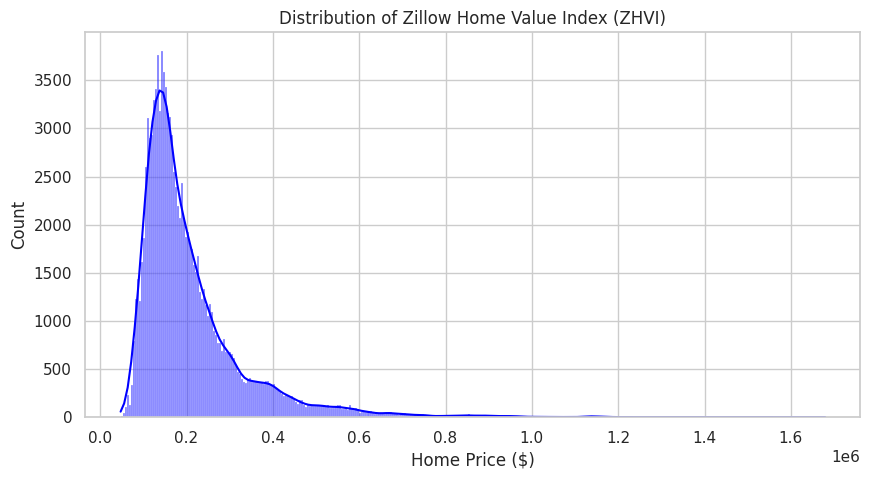

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(master_df['zhvi'], kde=True, color='blue')
plt.title('Distribution of Zillow Home Value Index (ZHVI)')
plt.xlabel('Home Price ($)')
plt.show()

### 🌡️ 2. Feature Correlation Matrix

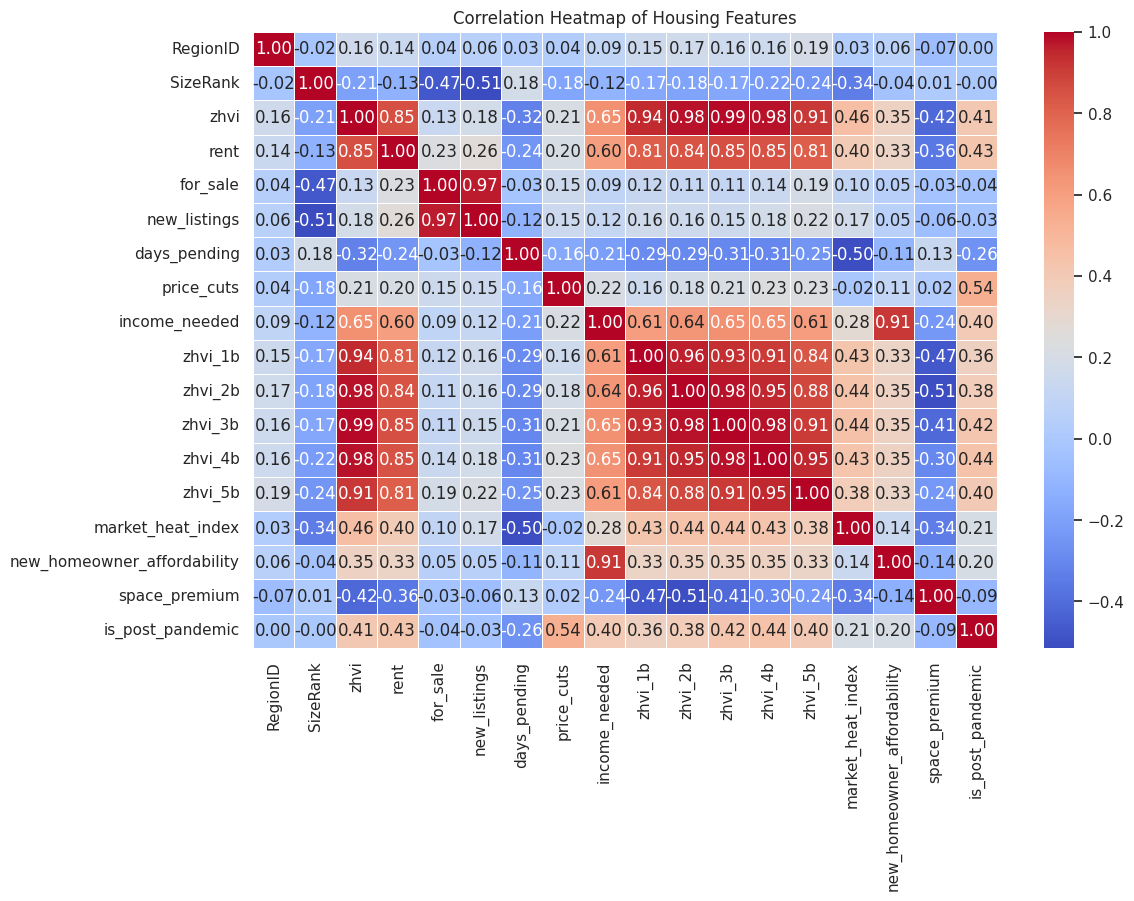

In [ ]:
# Select only numerical columns for correlation
numeric_cols = master_df.select_dtypes(include=[np.number]).columns
corr = master_df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Housing Features')
plt.show()

### 🏢 3. The "Space Premium" Trend

/tmp/ipykernel_8099/1823257848.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=master_df, x='Date', y='space_premium', ci=None)


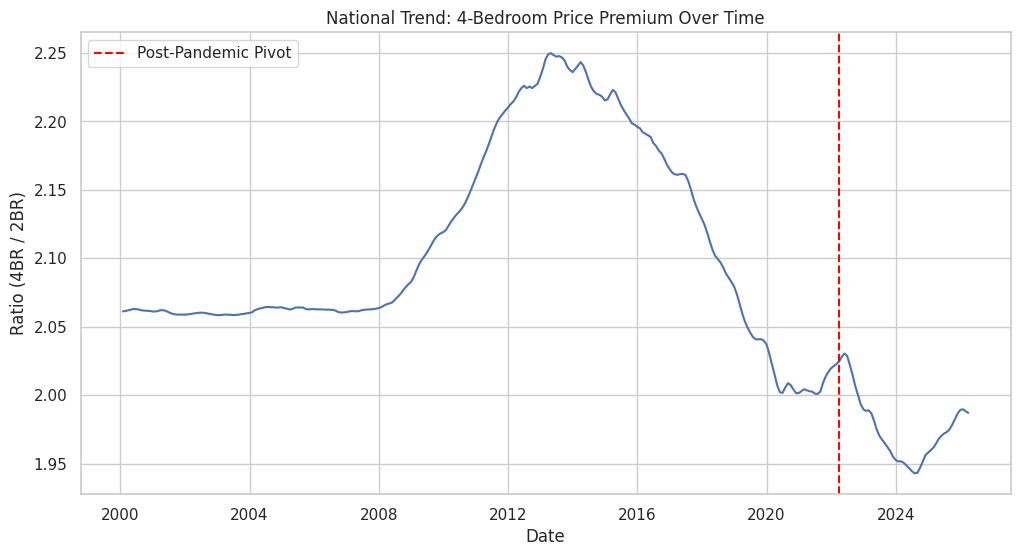

In [ ]:
sns.lineplot(data=master_df, x='Date', y='space_premium', ci=None)
plt.axvline(pd.to_datetime('2022-04-01'), color='red', linestyle='--', label='Post-Pandemic Pivot')
plt.title('National Trend: 4-Bedroom Price Premium Over Time')
plt.ylabel('Ratio (4BR / 2BR)')
plt.legend()
plt.show()

## 🛠️ Section 2: Feature Encoding & Chronological Splitting
We apply **Label Encoding** to State names and **One-Hot Encoding** to Region types. To prevent data leakage, we use a chronological split (80/20) rather than a random shuffle.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import pandas as pd

# 1. Sort by date first (Essential for time-series)
master_df = master_df.sort_values('Date')

# 2. Set a cut-off date for 'Post-Pandemic' exposure
split_date = '2023-01-01'
train_df = master_df[master_df['Date'] < split_date].copy()
test_df = master_df[master_df['Date'] >= split_date].copy()

# --- NEW: Safe Target Encoding Implementation ---
# Calculate means from training set only to prevent leakage
state_target_means = train_df.groupby('StateName')['zhvi'].mean()

# Map the means to create the 'state_encoded' feature
train_df['state_encoded'] = train_df['StateName'].map(state_target_means)
test_df['state_encoded'] = test_df['StateName'].map(state_target_means)

# Handle unseen states in the test set using the global training mean
global_train_mean = train_df['zhvi'].mean()
test_df['state_encoded'] = test_df['state_encoded'].fillna(global_train_mean)
# ------------------------------------------------

# 3. Define X and y
# Note: 'StateName' is dropped, but our new 'state_encoded' is NOT in this list, so it stays.
cols_to_drop = [
    'RegionID', 'RegionName', 'Date', 'RegionType', 'StateName', 'SizeRank',
    'zhvi', 'zhvi_1b', 'zhvi_2b', 'zhvi_3b', 'zhvi_4b', 'zhvi_5b',
    'new_listings', 'income_needed'
]

X_train_raw = train_df.drop(columns=cols_to_drop)
X_test_raw = test_df.drop(columns=cols_to_drop)
y_train = train_df['zhvi']
y_test = test_df['zhvi']

print(f"Training on data up to {train_df['Date'].max()}")
print(f"Testing on data from {test_df['Date'].min()} to {test_df['Date'].max()}")
print(f"Feature count: {X_train_raw.shape[1]} (New feature 'state_encoded' included)")

Training on data up to 2022-12-31 00:00:00
Testing on data from 2023-01-31 00:00:00 to 2026-03-31 00:00:00
Feature count: 9 (New feature 'state_encoded' included)


In [ ]:
# 1. Standardization (Mean=0, Variance=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Convert to DataFrames
X_train = pd.DataFrame(X_train_scaled, columns=X_train_raw.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test_raw.columns)

# 2. Export to Google Drive
export_folder = os.path.join(base_path, 'Model_Ready_Exports')
if not os.path.exists(export_folder): os.makedirs(export_folder)

sets = {
    'X_train.parquet': X_train, 'X_test.parquet': X_test,
    'y_train.parquet': y_train.to_frame(), 'y_test.parquet': y_test.to_frame()
}

for name, data in sets.items():
    data.to_parquet(os.path.join(export_folder, name), index=False)

# Save Scaler and Label Mapping
joblib.dump(scaler, os.path.join(export_folder, 'feature_scaler.pkl'))

print(f"✨ Successfully exported 4 datasets and scaler to: {export_folder}")